In [1]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [2]:
# Checking if processing rods or GB/GI

processing_type = input("Are you processing shapes (Y) or GB/GI ratio's (N)?")

In [3]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
#folder_path = filedialog.askdirectory(title='Select input folder')
#save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

    
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=1000, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")


If pop up box not seen minimise spyder and select folder wanted for analysis


In [4]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink
c3= '#744db0' # purple

GB_U_color = "5CBBFF"
GI_U_color = "003357"
GB_P_color = "D69AAB"
GI_P_color = "8D1730"

In [5]:
# Gaussian fitting (Multigaussian) 
# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


In [ ]:
#Processing for hexagons, rods and other
# Setting up initial parameters to change from fitting: 
# number of rows in txt files to skip
rows = 3


# General iteration for creating values: 
def fit_gaussian (file_name, rows): 
    # Pass the file path (string) to open() with a specified encoding
    with open(file_name, 'r', encoding='utf-8', errors='replace') as f:
        data = np.loadtxt(f, skiprows=rows)
    #with open(file_name, 'r', encoding='utf-8', errors='replace') as f:
    #        data = np.loadtxt(f, skiprows=rows)
    #data = np.loadtxt(file_name, skiprows=rows)
    #file_name.close()
    x_data = data[:, 0]
    y_data = data[:, 1]
    # Estimate initial guess and peak count
    initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    popt, _ = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    y_fit=multi_gaussian(x_fit,*popt)
    peak_index_max=np.argmax(y_fit)
    peak_centre=x_fit[peak_index_max]
    #For finding min and max *i.e. either side of the peaks. 
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

    # Identify the highest peak
    #highest = max(gaussians, key=lambda g: g['amp'])
    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
    # FWHM = 2.355 * sigma
    fwhm = 2.355 * highest['wid']
    min_spread = highest['cen'] - fwhm / 2
    max_spread = highest['cen'] + fwhm / 2
    return x_data, y_data, x_fit, y_fit, peak_centre, fwhm, min_spread, max_spread


In [7]:
# Gaussian fitting and plotting for grain shapes. Comment out any ones that are not wanted. 
def grain_shapes():
    print("If pop up box not seen minimise spyder and select folder wanted for analysis")
    hex_file_path = filedialog.askopenfilename(title='Select hexagons .txt file')#, filetypes =[ "*.txt"])
#    rod_file_path = filedialog.askopenfilename(title='Select rods .txt file')#,filetypes = ["*.txt"])
    other_file_path = filedialog.askopenfilename(title='Select other grains .txt file')#,filetypes = ["*.txt"])
    if hex_file_path and other_file_path:# and rod_file_path:
        # Hexagons
        hex_x_raw, hex_y_raw, hex_x, hex_y, hex_peak, hex_fwhm, hex_min, hex_max = fit_gaussian(hex_file_path, rows)
        # Rods
#        rod_x_raw, rod_y_raw, rod_x, rod_y, rod_peak, rod_fwhm, rod_min, rod_max = fit_gaussian(rod_file_path, rows)
        # Other
        other_x_raw, other_y_raw, other_x, other_y, other_peak, other_fwhm, other_min, other_max = fit_gaussian(other_file_path, rows)
#Hexagons
#    hex_x_raw, hex_y_raw, hex_x, hex_y, hex_peak, hex_fwhm, hex_min, hex_max = fit_gaussian(hex_file, rows)
    # Rods
#    rod_x_raw, rod_y_raw, rod_x, rod_y, rod_peak, rod_fwhm, rod_min, rod_max = fit_gaussian(rod_file, rows)
    # Other
#    other_x_raw, other_y_raw, other_x, other_y, other_peak, other_fwhm, other_min, other_max = fit_gaussian(other_file, rows)

    #Plotting functions: 
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both', labelsize=30)
    ax.margins (0.5,0.5)
    plt.xlabel("CPD (V)", size = 30)
    ax.autoscale(enable=None, axis="x", tight=True)
    min_axis=[np.min(other_x_raw), np.min(other_x), np.min(hex_x_raw), np.min(hex_x)]#, np.min(rod_x_raw), np.min(rod_x)]
    max_axis = [np.max(other_x_raw), np.max(other_x), np.max(hex_x_raw), np.max(hex_x)]#, np.max(rod_x_raw), np.max(rod_x)]
    ax.set_xlim(np.min(min_axis)-0.01, np.max(max_axis)+0.01)
    plt.ylabel("Distribution (V$^{-1}$)", fontsize=30)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 

    plt.scatter(hex_x_raw, hex_y_raw, label=f"Hexagons", color=c1, s=10)
    plt.plot(hex_x, hex_y, label=f"_nolegend_", color=c1, linewidth=2)
#    plt.scatter(rod_x_raw, rod_y_raw, label=f"Rods", color=c3, s=10)
#    plt.plot(rod_x, rod_y, label=f"_nolegend_", color=c3, linewidth=2)
    plt.scatter(other_x_raw, other_y_raw, label=f"Other", color=c2, s=10)
    plt.plot(other_x, other_y, label=f"_nolegend_", color=c2, linewidth=2)
    plt.legend(loc='upper left', fontsize = 14)

    #uncomment for saving figures
    '''save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path,filename='GrainShapes_MultiGaussian.jpeg')
    output_file = os.path.join(save_path, 'GrainShapes_Analysis_Output.txt')
    with open(output_file, 'w') as f:
        # Use a list to store and print the output
        output_lines = [
            "Hexagons peak = " + str(hex_peak),
            "Hexagons fwhm = " + str(hex_fwhm),
            "Hexagons min, max spread = " + str(hex_min) + ", " + str(hex_max),
#            "Rods peak = " + str(rod_peak),
#            "Rods fwhm = " + str(rod_fwhm),
#            "Rods min, max spread = " + str(rod_min) + ", " + str(rod_max),
            "Other peak = " + str(other_peak),
            "Other fwhm = " + str(other_fwhm),
            "Other min, max spread = " + str(other_min) + ", " + str(other_max)
            ]
        # Print to both console and file
        for line in output_lines:
            print(line)
            f.write(line + '\n')'''

    plt.show()

In [ ]:
#Gaussian fitting and plotting for GB/GI . Comment out any ones that are not wanted. 
def grain_boundaries(GB_file_1, GI_file_1, pixels, save_path, GB_colour='input',GI_colour='input'):
    
    #Unpassivated
    GB_x_raw_1, GB_y_raw_1, GB_x_1, GB_y_1, GB_peak_1, GB_fwhm_1, GB_min_1, GB_max_1 = fit_gaussian(GB_file_1, rows)
    GI_x_raw_1,GI_y_raw_1, GI_x_1, GI_y_1, GI_peak_1, GI_fwhm_1, GI_min_1, GI_max_1 = fit_gaussian(GI_file_1, rows)
    peak_diff_1 = GB_peak_1 - GI_peak_1

    #Plotting functions: 
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both')#, labelsize=50)
    ax.margins (0.5,0.5)
    plt.xlabel("CPD (V)")#, size = 50)
    min_axis=[np.min( GB_x_raw_1), np.min(GB_x_1)]#, np.min( GB_x_raw_2), np.min(GB_x_2)]
    max_axis = [np.max( GB_x_raw_1), np.max(GB_x_1)]#, np.max( GB_x_raw_2), np.max(GB_x_2)]
    ax.set_xlim(np.min(min_axis)-0.01, np.max(max_axis)+0.01)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)")#, fontsize=50)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
    #Plotting
    plt.scatter(GB_x_raw_1, GB_y_raw_1, label=f"GB Unpassivated", color=GB_colour, s=10)
    plt.plot(GB_x_1, GB_y_1, label=f"_nolegend_", color=GB_colour, linewidth=2)
    plt.scatter(GI_x_raw_1, GI_y_raw_1, label=f"GI Unpassivated", color=GI_colour, s=10)
    plt.plot(GI_x_1, GI_y_1, label=f"_nolegend_", color=GI_colour, linewidth=2)
    plt.legend(loc='upper right', fontsize = 20)
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path,filename=f'GrainBoundary_Interior_MultiGaussian_{pixels*20}_nm.jpeg')
    output_file = os.path.join(save_path, f'GrainBoundaries_analysis_output_{pixels*20}_nm.txt')
    with open(output_file, 'w') as f:
        # Use a list to store and print the output
        output_lines = [
            "Unpassivated:",
            "Grain boundary peak = " + str(GB_peak_1),
            "Grain boundary fwhm = " + str(GB_fwhm_1),
            "Grain boundary min, max spread = " + str(GB_min_1) + ", " + str(GB_max_1),
            "Grain interior peak = " + str(GI_peak_1),
            "Grain interior fwhm = " + str(GI_fwhm_1),
            "Grain interior min, max spread = " + str(GI_min_1) + ", " + str(GI_max_1),
            "Diff of GB/GI =" + str(GB_peak_1 - GI_peak_1),
        ]
        #Print to both console and file
        for line in output_lines:
        #    print(line)
            f.write(line + '\n')
    return peak_diff_1           
    #plt.show()
    

In [28]:
def call_text_files(type='input'):
    # Define the folder path containing the numbered text files
    folder_path = filedialog.askdirectory(title=f'Select the folder containing the 1-5 grain {type} files')

    # Dictionary to hold the assigned file paths
    gb_files = {}
    if folder_path:
    # 2. Iterate through files in the selected folder
        for filename in os.listdir(folder_path):
         # 3. Check if the file is a numbered .txt file (e.g., '1.txt')
         if filename.endswith(".txt") and filename[:-4].isdigit():
            
            # Extract the number (1 to 5) from the filename
            file_number = int(filename[:-4])
            
            # We only care about files 1 through 5
            if 1 <= file_number <= 5:
                # Construct the full file path
                full_path = os.path.join(folder_path, filename)
                # Assign the path to the dictionary using the number as the key
                gb_files[file_number] = full_path

    # 4. Assign the paths to your original variable names for easy substitution
        if len(gb_files) == 5:
            GB_file_1 = gb_files[1]
            GB_file_2 = gb_files[2]
            GB_file_3 = gb_files[3]
            GB_file_4 = gb_files[4]
            GB_file_5 = gb_files[5]
        
            print("Files successfully assigned:")
            #print(f"File 1: {GB_file_1}")
            return GB_file_1,GB_file_2, GB_file_3, GB_file_4,GB_file_5
        else:
            print(f"Error: Found {len(gb_files)} out of 5 required numbered files (1.txt to 5.txt).")
    else: 
       print("No folder selected. ")

In [ ]:
#Function for pulling out GB/GI: 
def GB_diff_processing (dataset='dataset',colour1='colour', colour2='colour'): 
    # Comment out however many pixel images you want 
    save_path=filedialog.askdirectory(title=f'Select the folder to save files')
    GB_file_1,GB_file_2, GB_file_3, GB_file_4,GB_file_5 = call_text_files(type=f'boundaries {dataset}')
    GI_file_1,GI_file_2, GI_file_3, GI_file_4,GI_file_5 = call_text_files(type=f'interiors {dataset}')

    peak_diff_1  = grain_boundaries(GB_file_1, GI_file_1, save_path, 1,colour1,colour2)
    peak_diff_2 =   grain_boundaries(GB_file_2, GI_file_2, 2,save_path, colour1,colour2)
    peak_diff_3  = grain_boundaries(GB_file_3, GI_file_3, 3,save_path,colour1,colour2)
    peak_diff_4 = grain_boundaries(GB_file_4, GI_file_4, 4,save_path,colour1,colour2)
    peak_diff_5  = grain_boundaries(GB_file_5, GI_file_5, 5,save_path,colour1,colour2)
    
    #x_pixels = [1,2,3,4,5]#,6,7,8,9,10]
    #x_nm = [20,40,60,80,100]
    y_peaks = [peak_diff_1, peak_diff_2, peak_diff_3, peak_diff_4, peak_diff_5]#,peak_diff_6, peak_diff_7, peak_diff_8, peak_diff_9, peak_diff_10]
    y_peaks_adjusted = []
    for x in y_peaks: 
        x=x*1000
        y_peaks_adjusted.append(round(x,4))
    return y_peaks_adjusted

Files successfully assigned:
Files successfully assigned:
If pop up box not seen minimise spyder and select folder wanted for analysis


TypeError: expected str, bytes or os.PathLike object, not int

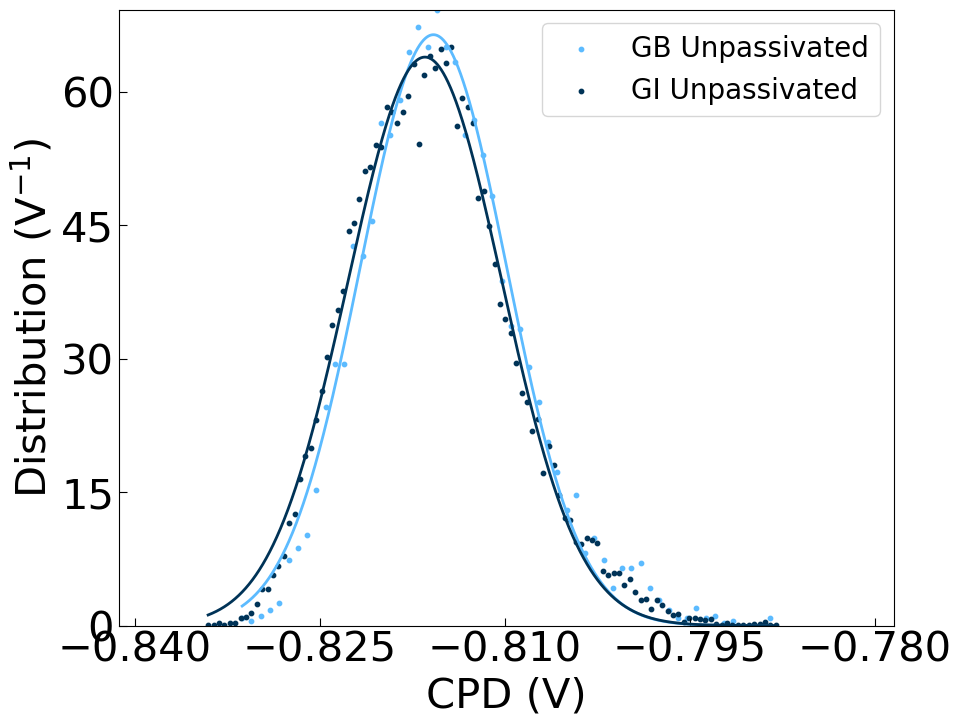

In [34]:
if processing_type == 'Y':
    grain_shapes()
elif processing_type == 'N':

  Unpass_Dark_CPD= GB_diff_processing (dataset='Unpass_Dark_CPD',colour1= "#5CBBFF",colour2="#003357")
  Unpass_On_CPD= GB_diff_processing (dataset='Unpass_On_CPD',colour1= "#5CBBFF",colour2="#003357")
  Unpass_Off_CPD = GB_diff_processing (dataset='Unpass_Off_CPD',colour1= "#5CBBFF",colour2="#003357")
  Unpass_On_SPV= GB_diff_processing (dataset='Unpass_On_SPV',colour1= "#5CBBFF",colour2="#003357")
  Unpass_Off_SPV = GB_diff_processing (dataset='Unpass_Off_SPV',colour1= "#5CBBFF",colour2="#003357")
  Pass_Dark_CPD= GB_diff_processing (dataset='Pass_Dark_CPD',colour1="#D69AAB",colour2="#8D1730")
  Pass_On_CPD= GB_diff_processing (dataset='Pass_On_CPD',colour1="#D69AAB",colour2="#8D1730")
  Pass_Off_CPD = GB_diff_processing (dataset='Pass_Off_CPD',colour1="#D69AAB",colour2="#8D1730")
  Pass_On_SPV= GB_diff_processing (dataset='Pass_On_SPV',colour1="#D69AAB",colour2="#8D1730")
  Pass_Off_SPV = GB_diff_processing (dataset='Pass_Off_SPV',colour1="#D69AAB",colour2="#8D1730")

else:
    print ("No processing type selected or error in code")

In [ ]:
'''if processing_type =='N':
    # Plotting data:
    #Update peak diff to mV: 
    y_peaks_mV = []
    x_nm = [20,40,60,80,100]
    for x in y_peaks: 
        y_peaks_mV.append(x*1000)

    # Printing peak diffs to copy into
    plt.figure(figsize=(8, 5))
    plt.rcParams.update({'font.size': 30})
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both', labelsize=30)
    #ax.margins (0.3,0.3)
    plt.xlabel("Pixels", fontsize = 30)
    plt.ylabel("CPD Diff (mV)", fontsize=30)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    plt.scatter(x_nm, y_peaks_mV, label='Fit Peak', color='#8D1730', s=30)
    plt.autoscale(enable=True, axis='y', tight=False)
    #plt.ylim(-0.005, 0.005)
    #uncomment for saving figures
    save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path,filename='PixelsScatter.jpeg')
    #Automatically adjust the y-axis
    plt.show()
else: 
    print ('No scatter needed')'''

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPVSlabs\FullScatternm_CPD_Unpassivated.jpeg


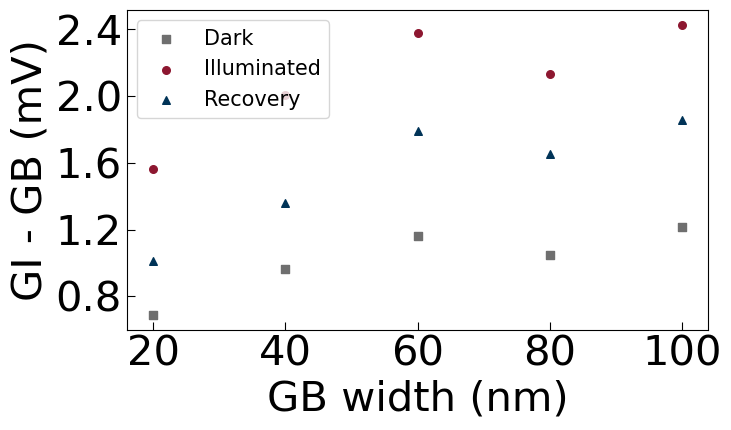

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPVSlabs\FullScatternm_SPV_Unpassivated.jpeg


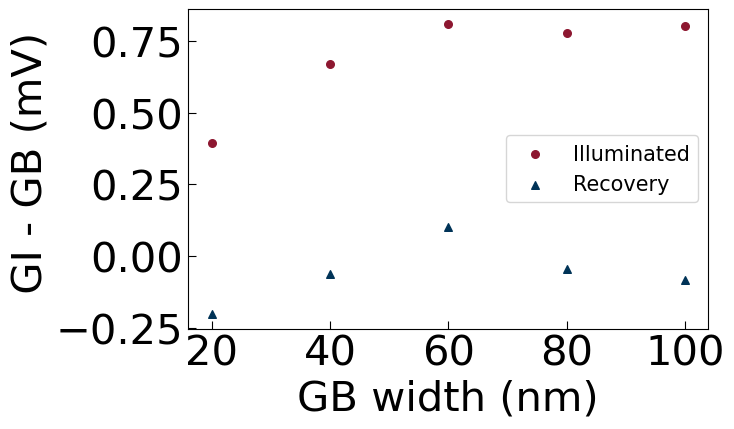

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPVSlabs\FullScatternm_CPD_Passivated.jpeg


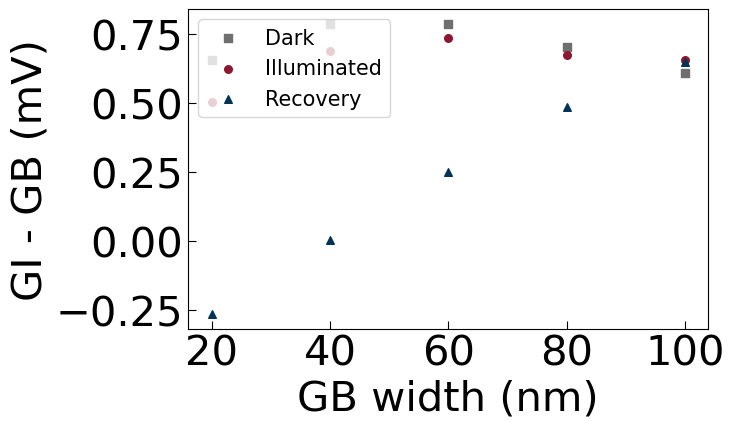

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPVSlabs\FullScatternm_SPV_Passivated.jpeg


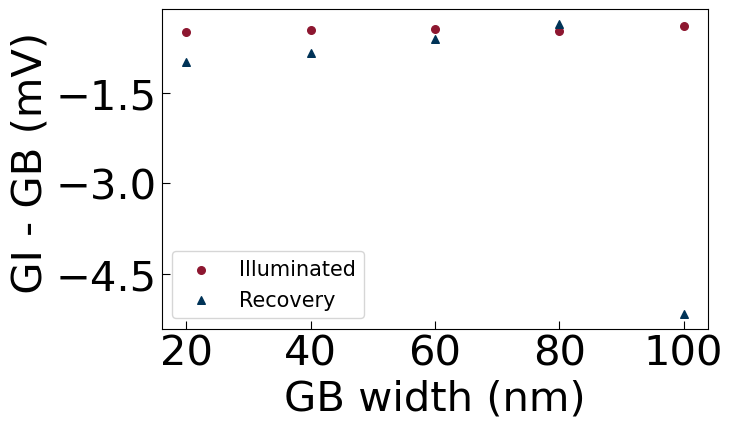

In [ ]:
#Plotting all arrays: 
x_nm = [20,40,60,80,100]
save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
# Plotting data: 
plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 30})
ax = plt.gca()
ax.tick_params(direction='in', length=6)
ax.tick_params(axis='both', labelsize=30)
#ax.margins (1,1)
plt.xlabel("GB width (nm)", fontsize = 30)
plt.ylabel("GI - GB (mV)", fontsize=30)
# Limit number of ticks
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
plt.scatter(x_nm,Unpass_Dark_CPD, label='Dark', color='#6F6F6F', marker ='s' , s=30)
plt.scatter(x_nm,Unpass_On_CPD, label='Illuminated', color='#8D1730', marker= 'o', s=30)
plt.scatter(x_nm,Unpass_Off_CPD, label='Recovery', color='#003357', marker = '^', s=30)
plt.autoscale(enable=True, axis='y', tight=False)
plt.legend(loc = 'upper left', fontsize = 15)
#plt.ylim(-0.005, 0.005)
#uncomment for saving figures
#save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
fig=plt.gcf()
save_plot_to_folder(fig, save_path,filename='FullScatternm_CPD_Unpassivated.jpeg')
#Automatically adjust the y-axis
plt.show()


# Plotting data:
# #Update peak diff to mV: 
plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 30})
ax = plt.gca()
ax.tick_params(direction='in', length=6)
ax.tick_params(axis='both', labelsize=30)
#ax.margins (1,1)
plt.xlabel("GB width (nm)", fontsize = 30)
plt.ylabel(" GI - GB (mV)", fontsize=30)
# Limit number of ticks
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
plt.scatter(x_nm,Unpass_On_SPV, label='Illuminated', color='#8D1730', marker= 'o', s=30)
plt.scatter(x_nm,Unpass_Off_SPV, label='Recovery', color='#003357', marker = '^', s=30)
plt.autoscale(enable=True, axis='y', tight=False)
plt.legend(fontsize = 15)
#plt.ylim(-0.005, 0.005)
#uncomment for saving figures
fig=plt.gcf()
save_plot_to_folder(fig, save_path,filename='FullScatternm_SPV_Unpassivated.jpeg')
#Automatically adjust the y-axis
plt.show()

# Plotting data: 
plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 30})
ax = plt.gca()
ax.tick_params(direction='in', length=6)
ax.tick_params(axis='both', labelsize=30)
#ax.margins (1,1)
plt.xlabel("GB width (nm)", fontsize = 30)
plt.ylabel("GI - GB (mV)", fontsize=30)
# Limit number of ticks
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
plt.scatter(x_nm,Pass_Dark_CPD, label='Dark', color='#6F6F6F', marker ='s' , s=30)
plt.scatter(x_nm,Pass_On_CPD, label='Illuminated', color='#8D1730', marker= 'o', s=30)
plt.scatter(x_nm,Pass_Off_CPD, label='Recovery', color='#003357', marker = '^', s=30)
plt.autoscale(enable=True, axis='y', tight=False)
plt.legend(loc = 'lower right', fontsize = 15)
#plt.ylim(-0.005, 0.005)
#uncomment for saving figures
#save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
fig=plt.gcf()
save_plot_to_folder(fig, save_path,filename='FullScatternm_CPD_Passivated.jpeg')
#Automatically adjust the y-axis
plt.show()


# Plotting data:
# #Update peak diff to mV: 
plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 30})
ax = plt.gca()
ax.tick_params(direction='in', length=6)
ax.tick_params(axis='both', labelsize=30)
#ax.margins (1,1)
plt.xlabel("GB width (nm)", fontsize = 30)
plt.ylabel(" GI - GB (mV)", fontsize=30)
# Limit number of ticks
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
plt.scatter(x_nm,Pass_On_SPV, label='Illuminated', color='#8D1730', marker= 'o', s=30)
plt.scatter(x_nm,Pass_Off_SPV, label='Recovery', color='#003357', marker = '^', s=30)
plt.autoscale(enable=True, axis='y', tight=False)
plt.legend(fontsize = 15)
#plt.ylim(-0.005, 0.005)
#uncomment for saving figures
fig=plt.gcf()
save_plot_to_folder(fig, save_path,filename='FullScatternm_SPV_Passivated.jpeg')
#Automatically adjust the y-axis
plt.show()

In [14]:
print(Pass_Off_CPD)

[-0.3, 0.0, 0.2, 0.5, 0.6]
